# One dimensional dummy problem

## Problem Statement

The model will have diffusion of hydrogen gas and convection with a flow speed that is calculated from the pressure. The battery will be on the domain $\Omega = (0,L)$, where $L$ is the length of the battery. The left boundary will be the inflow of hydrogen gas, and the right boundary will be the outflow of hydrogen gas. Since we now also model the pressure we can assume pure hydrogen gas everywhere, and adjust the gas absorption with its intended pressure dependency. It also assumes constant temperature, and ideal gas law: $p=\rho_g RT$. The model also takes into account viscous dissipation of a poreous medium. It is summarized in the following system of equations:
\begin{equation}
\left\{\begin{aligned}
\rho_g \partial_t v &=-RT\partial_x\rho_g-\rho_g v \partial_x v+\mu\partial_x^2 v -S\\
\epsilon\partial_t\rho_g&=-\partial_x (\rho_g v)+ \mu_\epsilon\partial_x^2\rho_g-\dot m \\
(1-\epsilon)\partial_t \rho_s &= \dot m 
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density of H2 in the air, now seen as a true density, instead of a ratio. $\rho_s$ is the amount of hydrogen in the solid Metal Organic Framework, $v$ is the flow speed, $\mu$ is the viscosity of the gas, and $\mu_\epsilon$ is the diffusion coefficient, this is required numerically to avoid instabilities and oscilations (even when using upwind schemes). The absorption and viscous dissipation are given by:
\begin{align}
    \dot m &= A\log(\frac{p_g}{p_{eq,a}})(\rho_{sat}-\rho_s)\\
    S &= \frac{\mu}{K}v
\end{align}
under IC:
\begin{equation}
\left\{ \begin{aligned}
\rho_g(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}
(the solid doesn't need a boundary condition since it is not really coupled to its surroundings), and BC:
\begin{equation}
\left\{\begin{aligned}
    v(L,t) &= 0\\
\rho_g(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
\end{aligned}\right.
\end{equation}
where we use a steep increase in density at the inlet to simulate a step function, since a discontinuity gives extremely low initial time steps. The BC for the velocity is a no-slip condition at the outlet, and a zero gradient at the inlet. 

We will expand $\rho_g$, $\rho_s$, and $v$ as:
\begin{equation}
    \begin{aligned}
         v(x,t) &= \sum_j v^j(t) \phi^j(x) \\
    \rho_g(x,t) &= \sum_i \rho_{g}^i(t) \phi^i(x) \\
    \rho_s(x,t) &= \sum_i \rho_{s}^i(t) \phi^i(x) \\
    \end{aligned}
\end{equation}
with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
        v^1        \\ \vdots \\ v^{N_2}      \\
        \rho_{g}^1 \\ \vdots \\ \rho_{g}^{N_1} \\ 
        \rho_{s}^1 \\ \vdots \\ \rho_{s}^{N_1} \\ 
    \end{pmatrix}
\end{equation}

we will also need an expansion of the mass transfer term:
\begin{equation}
    \dot m(x,t) = \sum_i \dot m^i(t) \phi^i(x)
\end{equation}
which we will approximate at the terms using our knowledge that on nodes the only non-zero basis function is the one corresponding to that node, so we can approximate the mass transfer term as:
\begin{equation}
    \dot m^i(t) = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v} 
    % & \text{negative sign due to integration by parts}
    \\
    -\frac{\mu}{K}\sum_i\left(\int \phi^k\phi^i \, dx \right)v_i&= S \mathbf{v}
\end{aligned}
\end{equation}

For the convection term we have:
\begin{equation}
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
\end{equation}
which we will approximate using a quadrature rule.


Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}+S\mathbf{v}+C^{v}(\mathbf{v},\mathbf{\rho})
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the first term in the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{C}^{\rho_g}(\mathbf{v},\mathbf{\rho})
\end{equation}

The diffusion familiarly becomes:
\begin{equation}
    \mu_\epsilon\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) \rho_i = D_\epsilon \mathbf{\rho}
\end{equation}

The mass transfer term is given by:
\begin{equation}
\begin{aligned}
    \int\phi^k\dot m dx &= \int \phi^k \sum_i \dot m^i(t) \phi^i(x) dx \\
    &= \sum_i \dot m^i(t) \int \phi^k \phi^i dx \\
    &= M_{{\rho_g}} \dot{\mathbf{m}}
\end{aligned}
\end{equation}
where:
\begin{equation}
    \dot{m}^i = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### IMEX Scheme

I want to use a similar IMEX Scheme as I did in section 1.
Previously I had solved one with an IMEX scheme, where all linear parts were taken implicit, and non-linear parts explicit. Having

\begin{equation}
\begin{aligned}
M_v(\rho_g)\dot{v}&=P\rho_g+Dv + Sv + C^{v}(\mathbf{v},\mathbf{\rho})\\
\epsilon \,M_{\rho_g}\dot{\rho}_g&=D_\epsilon \rho_g-M_{{\rho_g}}\dot{\mathbf{m}}+C^{\rho_g}(\mathbf{v},\mathbf{\rho})\\
(1-\epsilon)M_{\rho_s}\dot{\rho}_s&=M_{{\rho_g}}\dot{\mathbf{m}}
\end{aligned}
\end{equation}
which can be summarized into:
\begin{equation}
\begin{aligned}
    M(u)\dot{u} &= L[u]+N(u) \\
    N(u) &= C(u)+M_m\begin{pmatrix}
    0 \\ -\dot{\mathbf{m}}(u) \\ \dot{\mathbf{m}}(u)
    \end{pmatrix} \\
    L &= \begin{pmatrix}
    D+S & P & 0 \\
    0 & D_\epsilon & 0 \\
    0 & 0 & 0
    \end{pmatrix} \\
    M_m &= \begin{pmatrix}
    0 & 0 & 0 \\
    0 & M_{{\rho_g}} & 0 \\
    0 & 0 & M_{{\rho_g}}
    \end{pmatrix}\\
    M &= \begin{pmatrix}
    M_v(\rho) & 0 & 0 \\
    0 & M_{\rho_g} & 0 \\
    0 & 0 & M_{\rho_s}
    \end{pmatrix}
\end{aligned} 
\end{equation}

Is it now again posible to IMEX scheme like:

\begin{equation}
\begin{aligned}
M_v(\rho^n)\frac{v^{n+1}-v^n}{\Delta t}&=P\rho^{n+1}+Dv^{n+1} \\
M_{\rho}\frac{\rho^{n+1}-\rho^n}{\Delta t}&=N(\rho^n, v^n)+BF^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
\begin{aligned}
\frac{M_{\rho}}{\Delta t}{\rho^{n+1}}&=N(\rho^n, v^n)+BF^n+\frac{M_{\rho}}{\Delta t}\rho^n \\
\left[\frac{M_v(\rho^n)}{\Delta t}-D\right]v^{n+1}-P\rho^{n+1}&=\frac{M_v(\rho^n)}{\Delta t}v^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
    Au^{n+1}=Bu^n+C
\end{equation}

where:

\begin{equation}
\begin{aligned}
    A(\mathbf{u}^n) &= \begin{pmatrix}
    \frac{M_v(\rho_g^n)}{\Delta t}-D-S & -P & 0 \\ 
    0 & \frac{M_{\rho_g}}{\Delta t}-D_\epsilon & 0 \\
    0 & 0 & \frac{M_{\rho_s}}{\Delta t}
    \end{pmatrix} \\
    B &= \begin{pmatrix}
    \frac{M_{\rho}}{\Delta t} & 0 \\
    0 & \frac{M_v(\rho^n)}{\Delta t}
    \end{pmatrix}\\
    C &= \begin{pmatrix}
        C^{v}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\ C^{\rho_g}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\0 
    \end{pmatrix}\\
    (M_{\rho})_{ij}&=\int \phi^i\phi^j\,dx \\
    P_{ij} &= -RT\int\phi^i\partial_x\phi^j\,dx \\
    D_{ij} &= -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx\\
    (M_v(\rho^n))_{kj}&=\sum_i\rho_i T_{kij} \\
    T_{ijk} &= \int \phi^i\phi^j\phi^k\,dx\\
    (N(\rho^n, v^n))_k&=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx\\
\end{aligned}
\end{equation}

In [1]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra #, OrderedCollections # mis is die laatste niet nodig hoop t niet

## Definitions

In [2]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 5.0;

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))

# Constants
R = 1.0;        # ideal gas constant - should be 8.314 J/(mol*K)
T = 1.0;        # temperature
A = 1.0;        # absorption coefficient 1/s
μ = 1.0;        # dynamic viscosity
μ_ϵ = 0.001;    # artificial diffusion coefficient
ϵ = 0.4         # porosity unitless

MA = 1.0;       # mass transfer coefficient
rho_sat = 1.0;  # saturation density
p_eqa = 1.0;    # equilibrium pressure
K = 1.0;        # permeability

name = "f. total pressure";

## grid

In [3]:
# generates grid
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho, rho_s, and v
ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefLine, 1}()
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [4]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [5]:
dof_range(dh, :rho)

3:4

In [6]:
# below only to find the dofs of the inlet boundary conditions, 
ch_rho_left = ConstraintHandler(dh)

dummy_rho = Dirichlet(
    :rho,
    left,
    (x, t) -> 0.0,
)

add!(ch_rho_left, dummy_rho)
close!(ch_rho_left)

inlet_rho_dofs = copy(ch_rho_left.prescribed_dofs)

ch_v_left = ConstraintHandler(dh)

dummy_v = Dirichlet(
    :v,
    left,
    (x, t) -> 0.0,
)

add!(ch_v_left, dummy_v)
close!(ch_v_left)

inlet_v_dofs = copy(ch_v_left.prescribed_dofs);

In [7]:
# linear constraint handler
ch_lin = ConstraintHandler(dh)
right_v = Dirichlet(
    :v,
    right,
    (x, t) -> 0
)
add!(ch_lin, right_v)

close!(ch_lin)
update!(ch_lin, 0.0)

# for the non-linear constraint I only need to constrain the inlet density to fullfill a total pressure bc
ch_ptot = ConstraintHandler(dh)    
inlet_p_tot = Dirichlet(
    :rho,
    left,
    (x, t) -> 2 
)
add!(ch_ptot, inlet_p_tot)
close!(ch_ptot)
update!(ch_ptot, 0.0)


In [8]:
# update!(ch, 0.0)

# for k in 1:length(ch.prescribed_dofs)
#     dof = ch.prescribed_dofs[k]
#     println("dof: ", dof, ", u:", u[dof], ", should be: ", ch.inhomogeneities[k]) #res[dof] = u[dof] - p.ch.bcvalues[dof]
# end
# println(ch.inhomogeneities[1])

In [9]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [10]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [11]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        Ferrite.reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [12]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -μ_ϵ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [13]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        Ferrite.reinit!(cellvalues_v, cell)
        Ferrite.reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * phi_k * dpsi_j[1] * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$
S_{ij} = \frac{\mu}{K}\int \phi^j\phi^i \, dx
$$

In [14]:
function doassemble_S!(
    S::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Se = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(S)
    v_dofs = dof_range(dh, :v)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Se,0)
        Ferrite.reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_v

                    phi_j = shape_value(cellvalues_v, q, j)

                    Se[v_dofs[k], v_dofs[j]] +=
                        -μ/K * phi_k * phi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Se)
    end
    return S
end

doassemble_S! (generic function with 1 method)

$$(M_v(\rho^n))_{kj}=\sum_i\rho_i T_{kij} $$

$$T_{ijk} = \int \phi^i\phi^j\phi^k\,dx$$

$$(M_v(\rho^n))_{kj}=\int\rho_h^n\phi^j\phi^k\,dx  $$

In [15]:
function doassemble_M_v!(
        M_v::SparseMatrixCSC,
        u::Vector{Float64},
        cellvalues_rho::CellValues,
        cellvalues_v::CellValues,
        dh::DofHandler
    )

    fill!(M_v, 0.0)

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    M_ve = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M_v)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rho_local = u[cell_dofs[rho_dofs]]

        fill!(M_ve,0)

        Ferrite.reinit!(cellvalues_v, cell)
        Ferrite.reinit!(cellvalues_rho, cell) 

        for q in 1:getnquadpoints(cellvalues_v)
            rho_q = sum(
                rho_local[j] *
                shape_value(cellvalues_rho,q,j)
                for j in 1:n_basefuncs_rho
            )

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(
                    cellvalues_v,
                    q,
                    k
                )
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(
                        cellvalues_v,
                        q,
                        i
                    )
                        
                    M_ve[v_dofs[k], v_dofs[i]] += rho_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, M_ve)
    end
    return M_v
end

doassemble_M_v! (generic function with 1 method)

$$(C^{\rho_g}(\rho^n, v^n))_k=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx$$

$$-\big[\phi^k\rho v\big]_{\delta \Omega} = \phi^k(0)v(0)\rho(0)$$

$$
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
$$

$$\dot M = \int \phi^k \log \left( \frac{RT\rho_g}{p_{eq}}\right)(\rho_{sat}-\rho_s)dx$$

In [16]:
function doassemble_NL_rhs!(
    N,
    u,
    params
)

    fill!(N,0)

    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          
            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)[1]
                for j in 1:length(v_local)
            )

            # Convection term of rhog                               
            for k in 1:length(rhog_local)
                dψ = shape_gradient(params.cellvalues_rhog,q,k)
                N[cell_dofs[rhog_dofs[k]]] += dψ[1] * v_q * rhog_q * dx
            end

            # Convection term of v
            for k in 1:length(v_local)
                ψ = shape_value(params.cellvalues_v,q,k)
                N[cell_dofs[v_dofs[k]]] += ψ * rhog_q * v_q *dv_q * dx            
            end

            # dot m =       A*log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end
    return N
end

doassemble_NL_rhs! (generic function with 1 method)

In [17]:
struct RHSparams
    A::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    cellvalues_v::CellValues
    facetvalues::FacetValues
    left
    M::SparseMatrixCSC          # {Float64,Int} ?
    ML::SparseMatrixCSC         # Linear part of mass Matrix
    rhs::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    assemble_mass!::Function    # Complete assembly of the mass matrix, including the nonlinear part
    assemble_rhs!::Function     # Complete assembly of the right-hand side, including the nonlinear part
    ch_lin::ConstraintHandler
    ch_ptot::ConstraintHandler
    inlet_v_dofs::Vector{Int}
    inlet_rho_dofs::Vector{Int}
end

In [18]:
function assemble_mass!(
        M::SparseMatrixCSC,
        u::Vector{Float64},
        params::RHSparams
    )

    copyto!(M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time

    # now for the non-linear part:

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)

    # loop over all cells
    for cell in CellIterator(params.dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rhog_local = u[cell_dofs[rhog_dofs]]

        fill!(Me,0)

        Ferrite.reinit!(params.cellvalues_v, cell)
        Ferrite.reinit!(params.cellvalues_rhog, cell) 

        for q in 1:getnquadpoints(params.cellvalues_v)
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:n_basefuncs_rhog
            )

            dx = getdetJdV(params.cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(params.cellvalues_v, q, k)
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(params.cellvalues_v, q, i)
                    Me[v_dofs[k], v_dofs[i]] += rhog_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)
    end
    return M
end

assemble_mass! (generic function with 1 method)

In [19]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          
            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)[1]
                for j in 1:length(v_local)
            )

            # Convection term of rhog                               
            for k in 1:length(rhog_local)
                dψ = shape_gradient(params.cellvalues_rhog,q,k)
                N[cell_dofs[rhog_dofs[k]]] += dψ[1] * v_q * rhog_q * dx
            end

            # Convection term of v
            for k in 1:length(v_local)
                ψ = shape_value(params.cellvalues_v,q,k)
                N[cell_dofs[v_dofs[k]]] += ψ * rhog_q * v_q *dv_q * dx            
            end

            # dot m =       A*log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end

    # left-boundary term: v rho ϕ^k |_{x=0}
    for facet in FacetIterator(params.dh, params.left)
        
        Ferrite.reinit!(params.facetvalues, facet)
        
        facet_dofs = facet.dofs
        rhog_local = view(u, facet_dofs[rhog_dofs])
        v_local   = view(u, facet_dofs[v_dofs])

        for q in 1:getnquadpoints(params.facetvalues)

            dborder = getdetJdV(params.facetvalues, q)
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.facetvalues,q,j)
                for j in 1:length(rhog_local)
            )
            v_q = sum(
                v_local[j] *
                shape_value(params.facetvalues,q,j)
                for j in 1:length(v_local)
            )               

            for k in 1:length(rhog_local)
                ψ = shape_value(params.facetvalues, q, k)
                N[facet_dofs[rhog_dofs[k]]] += v_q * rhog_q * ψ * dborder
            end
        end  
    end

    return N
end

assemble_rhs! (generic function with 1 method)

In [32]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
du     = similar(u)
du    .= 0.0
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
P     = allocate_matrix(dh)
S     = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)

doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)
doassemble_S!(S, cellvalues_v, dh)

# Linear parts of rhs
rhsL = P + D + Dp + S

# Initial condition
apply_analytical!(u, dh, :rho, x -> 1.0)
apply_analytical!(u, dh, :rho_s, x -> 0.0)
apply_analytical!(u, dh, :v,   x -> 0.0)

# Initial BC application
update!(ch_lin, 0.0)
apply!(u, ch_lin);

# Initial non-linear BC application
update!(ch_ptot, 0.0)
for k in eachindex(ch_ptot.prescribed_dofs)

    rho_dof = ch_ptot.prescribed_dofs[k]
    v_dof   = inlet_v_dofs[k]

    v = u[v_dof]
    p_tot_bc = ch_ptot.inhomogeneities[k]

    u[rho_dof] =
        p_tot_bc /
        (
            R * T +
            0.5 * v^2
        )
end


In [33]:
params = RHSparams(
    A, 
    R, 
    T, 
    p_eqa, 
    rho_sat, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    cellvalues_v,
    facetvalues,
    left,
    M,
    ML,
    rhs,
    rhsL,
    assemble_mass!,
    assemble_rhs!,
    ch_lin,
    ch_ptot,
    inlet_v_dofs,
    inlet_rho_dofs,
)

RHSparams(1.0, 1.0, 1.0, 1.0, 1.0, DofHandler{1, Grid{1, Line, Float64}}(SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}[SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}(DofHandler{1, Grid{1, Line, Float64}}(#= circular reference @-3 =#), OrderedCollections.OrderedSet{Int64}([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  91, 92, 93, 94, 95, 96, 97, 98, 99, 100]), [:v, :rho, :rho_s], Interpolation[Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}()], Int64[], 6)], [:v, :rho, :rho_s], [1, 2, 3, 4, 5, 6, 2, 7, 4, 8  …  296, 299, 297, 300, 298, 301, 299, 302, 300, 303], [1, 7, 13, 19, 25, 31, 37, 43, 49, 55  …  541, 547, 553, 559, 565, 571, 577, 583, 589, 595], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], true, Grid{1, Line, Float64}(Line[Line((1, 2)), Line((2, 3)), Line((3, 4)), Line((4, 5)), Line((5, 6)), Line((6, 7)), Line((7, 8)), Line((8, 9)), Line((9, 10)), Line((10, 11))  …  Line((91, 92)), Line((92, 93)), Line((93, 94)), Line((94, 95)), Line((95,

$$
res(du, u)
$$

In [ ]:
function res!(res, du, u, params, t)

    params.assemble_mass!(params.M, u, params)
    params.assemble_rhs!(params.rhs, u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.rhs

    # linear constraints
    update!(params.ch_lin, t)
    for k in 1:length(params.ch_lin.prescribed_dofs)

        dof = params.ch_lin.prescribed_dofs[k]
        value = params.ch_lin.inhomogeneities[k]

        res[dof] = u[dof] - value
        
    end

    # non-linear constraints
    update!(params.ch_ptot, t)
    for k in 1:length(params.ch_ptot.prescribed_dofs)

        rho_dof = params.ch_ptot.prescribed_dofs[k]
        v_dof   = params.inlet_v_dofs[k]
        ρ = u[rho_dof]
        v = u[v_dof]
        value = params.ch_ptot.inhomogeneities[k] # p_in
        p_tot = 0.5 * ρ * v^2 + params.R * params.T * ρ

        res[rho_dof] = p_tot - value
    end
end

# \rho_g op de inlet
# \rho_g = rho_t - (1/2) m v^2

res! (generic function with 1 method)

In [23]:
using DifferentialEquations

In [35]:
differential_vars = trues(length(u))

# the bc are not of the form du/dt = f(u), but rather f(u) = 0. So we need to set the differential_vars of the prescribed dofs to false
for dof in ch_lin.prescribed_dofs
    differential_vars[dof] = false
end
for dof in ch_ptot.prescribed_dofs
    differential_vars[dof] = false
end

tspan = (0.0, T1)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(
    prob, 
    initializealg=DiffEqBase.BrownFullBasicInit(),
    saveat=0.1, 
    reltol=1e-8, 
    abstol=1e-8
)

retcode: Success
Interpolation: 1st order linear
t: 51-element Vector{Float64}:
 0.0
 0.1
 0.2
 0.3
 0.4
 0.5
 0.6
 0.7
 0.8
 0.9
 1.0
 1.1
 1.2
 ⋮
 3.9
 4.0
 4.1
 4.2
 4.3
 4.4
 4.5
 4.6
 4.7
 4.8
 4.9
 5.0
u: 51-element Vector{Vector{Float64}}:
 [0.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0  …  0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0]
 [0.2481935717121134, 0.24815301570583356, 1.9402405527284206, 1.9162552458457311, 0.10701305900987589, 0.08688809472308118, 0.24795677768206856, 1.8774789411130643, 0.06642704603975819, 0.24739221255422122  …  7.502661274515854e-5, 0.0009637197428306796, 1.0026210552251036, 7.396267113752799e-5, 0.00048121203180559636, 1.0026043263489248, 7.332611570589472e-5, 0.0, 1.0025987549775437, 7.311423191099997e-5]
 [0.2911885827884459, 0.29114845269755785, 1.918657743590206, 1.9026794331301686, 0.19956593150944132, 0.18023919272863417, 0.29102773215130673, 1.8866506686716218, 0.16033262874603904, 0.2908255296648758  …  0.0023755411490380676, 0.003

In [26]:
sol.alg

Sundials.IDA{:Dense, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

## Plotting/animating

In [27]:
using Plots

In [39]:
U = Array(sol);

In [43]:
# double gif plot
foldername = name

U = Array(sol)

sol_v = U[v_global, :]
sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

# ptot = 1/2 rho v^2 + R T rho
ptot = 0.5 * sol_ρ .* sol_v.^2 .+ R * T * sol_ρ

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density gas",
        color=:blue,
        xlabel="x",
        ylabel="density",
        title="t = $(round(discrete_t[k], digits=3))",
        ylims=(0, ρmax),
        legend=:topright
    )

    plot!(
        p1,
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
    )

    plot!(
        p1,
        discrete_x,
        ptot[:, k],
        label="total pressure",
        color=:orange,
    )

    p2 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_Z8bLCv", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000042.png", "000043.png", "000044.png", "000045.png", "000046.png", "000047.png", "000048.png", "000049.png", "000050.png", "000051.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\f. total pressure\total pressure.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\f. total pressure\\total pressure.gif")
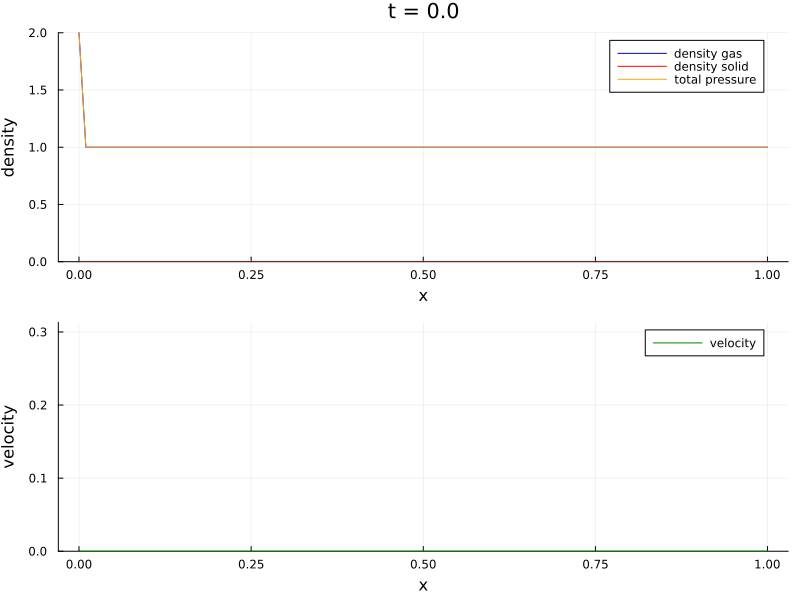

In [45]:
gif(anim, joinpath(foldername, "total pressure.gif"), fps=10)

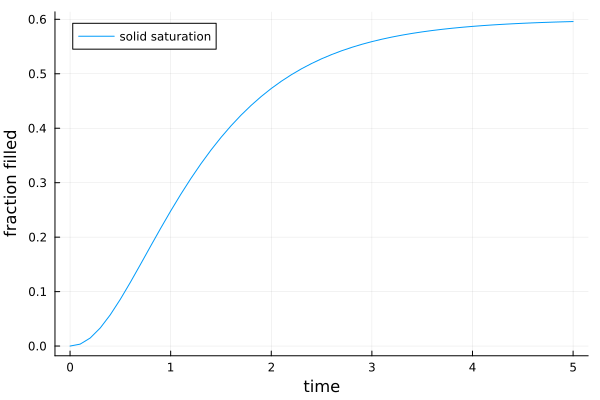

In [46]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = ML[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

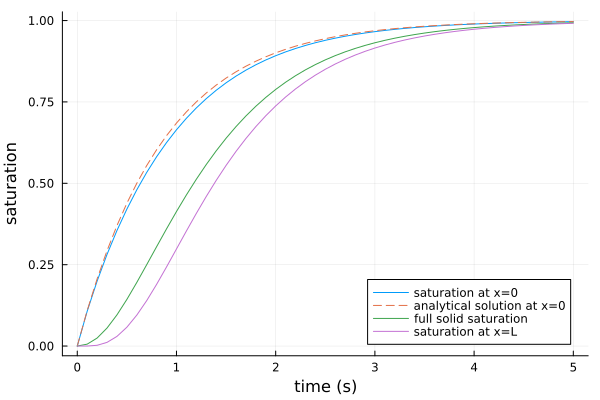

In [47]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [48]:
savefig(joinpath(foldername, "fill_fraction total pressure.png"))

"c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\f. total pressure\\fill_fraction total pressure.png"

In [ ]:
# report_figures_folder = "..\\report\\figures\\"
# folder = mkpath(report_figures_folder)
# name = "A.png"
# savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\model_4_result_IMEX.png"